In [3]:
import pandas as pd

df = pd.read_csv("../dataset/StressLevelDataset.csv")

df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

<Axes: >

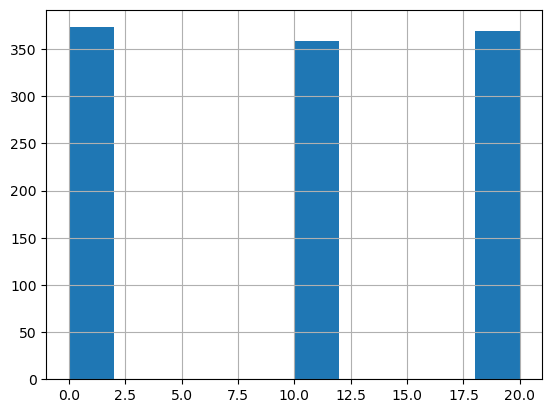

In [5]:
df["MindMeter"] = df["stress_level"] * 10
df.drop("stress_level", axis=1, inplace=True)
df["MindMeter"].hist()

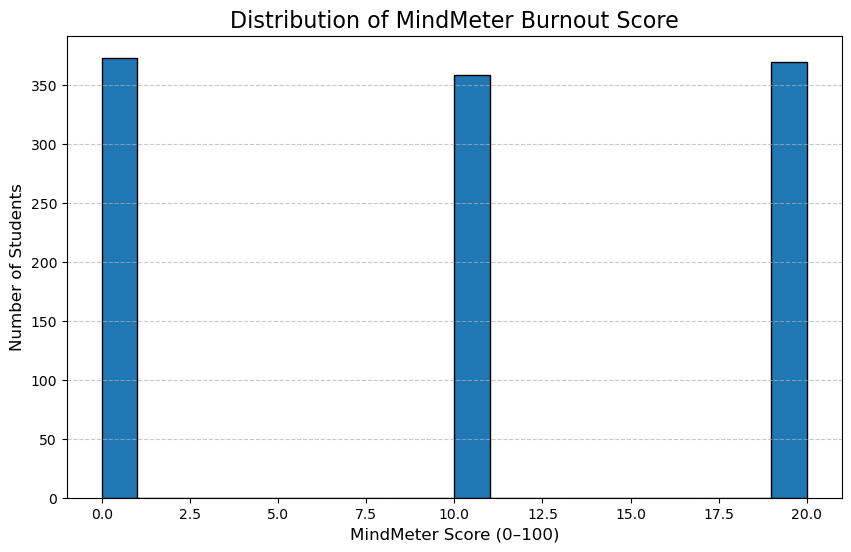

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df["MindMeter"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of MindMeter Burnout Score", fontsize=16)
plt.xlabel("MindMeter Score (0–100)", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

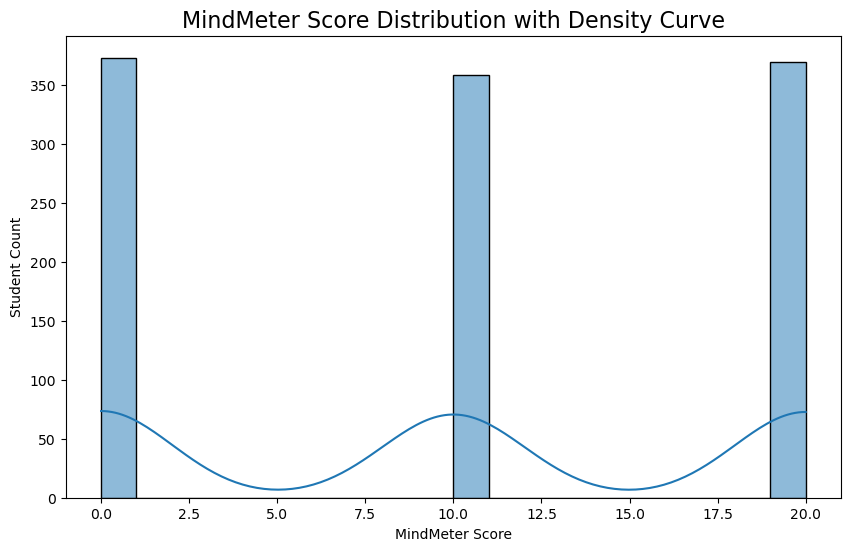

In [7]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    df["MindMeter"],
    bins=20,
    kde=True
)

plt.title("MindMeter Score Distribution with Density Curve", fontsize=16)
plt.xlabel("MindMeter Score")
plt.ylabel("Student Count")

plt.show()

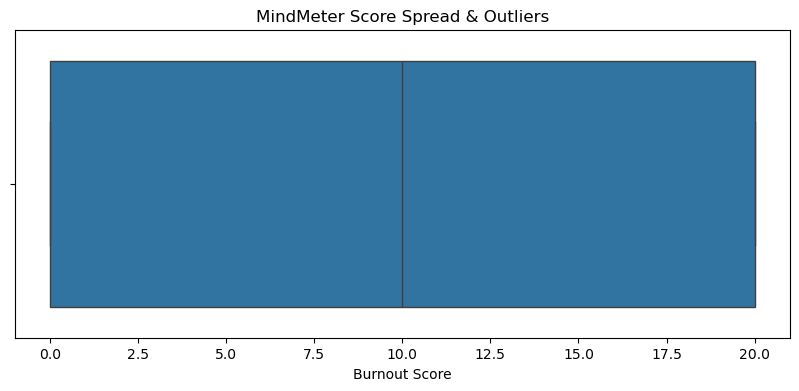

In [8]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["MindMeter"])

plt.title("MindMeter Score Spread & Outliers")

plt.xlabel("Burnout Score")

plt.show()

In [9]:
df["psychological_score"] = (
    df["anxiety_level"]
    + df["depression"]
    + (10 - df["self_esteem"])
    + df["mental_health_history"]
) / 4

In [10]:
df["academic_score"] = (
    df["study_load"]
    + (10 - df["academic_performance"])
    + df["future_career_concerns"]
    + df["peer_pressure"]
) / 4

In [11]:
df["lifestyle_score"] = (
    (10 - df["sleep_quality"])
    + df["headache"]
    + df["blood_pressure"]
    + df["breathing_problem"]
) / 4

In [12]:
df["social_score"] = (
    (10 - df["social_support"])
    + (10 - df["living_conditions"])
    + (10 - df["safety"])
    + df["bullying"]
) / 4

In [13]:
df[["MindMeter"]].head()

,MindMeter
0,10
1,20
2,10
3,20
4,10


In [14]:
df["MindMeter"] = (
    0.35 * df["psychological_score"]
    + 0.30 * df["academic_score"]
    + 0.20 * df["lifestyle_score"]
    + 0.15 * df["social_score"]
)

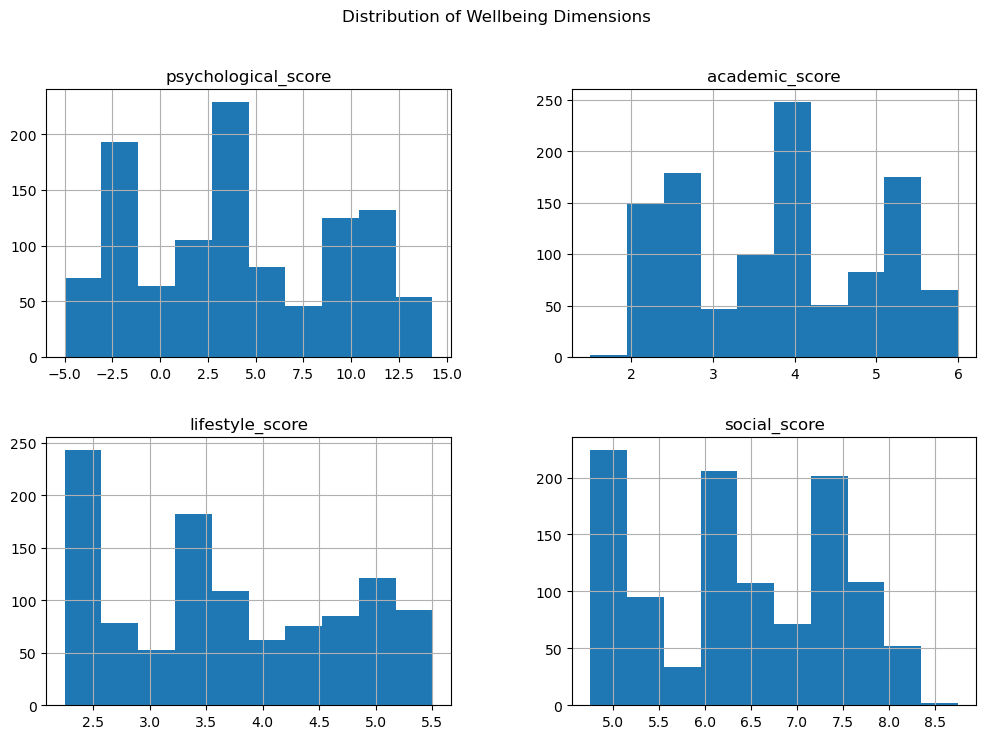

In [15]:
scores = [
    "psychological_score",
    "academic_score",
    "lifestyle_score",
    "social_score"
]

df[scores].hist(figsize=(12,8))
plt.suptitle("Distribution of Wellbeing Dimensions")
plt.show()

In [16]:
df.columns

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'MindMeter',
       'psychological_score', 'academic_score', 'lifestyle_score',
       'social_score'],
      dtype='object')

In [17]:
X = df.drop([
    "MindMeter",
    "psychological_score",
    "academic_score",
    "lifestyle_score",
    "social_score"
], axis=1)

y = df["MindMeter"]

In [18]:
print(X.shape)
print(y.shape)

(1100, 20)
(1100,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 0.14084431818181806
R2: 0.991267292298848


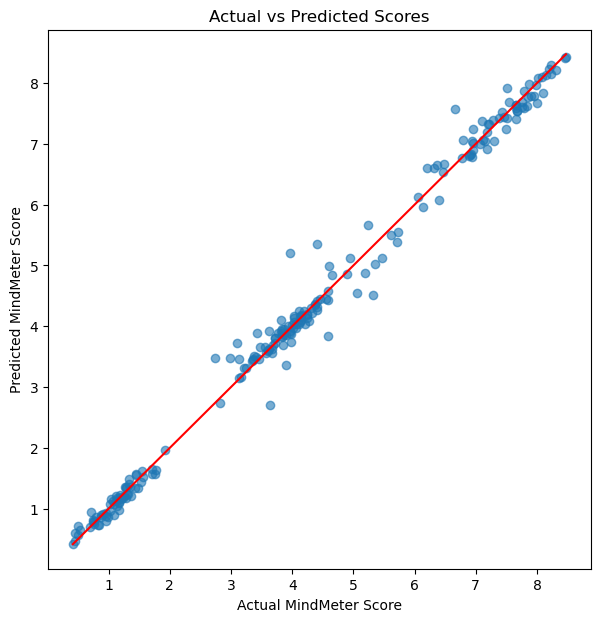

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, pred, alpha=0.6)

plt.xlabel("Actual MindMeter Score")
plt.ylabel("Predicted MindMeter Score")
plt.title("Actual vs Predicted Scores")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

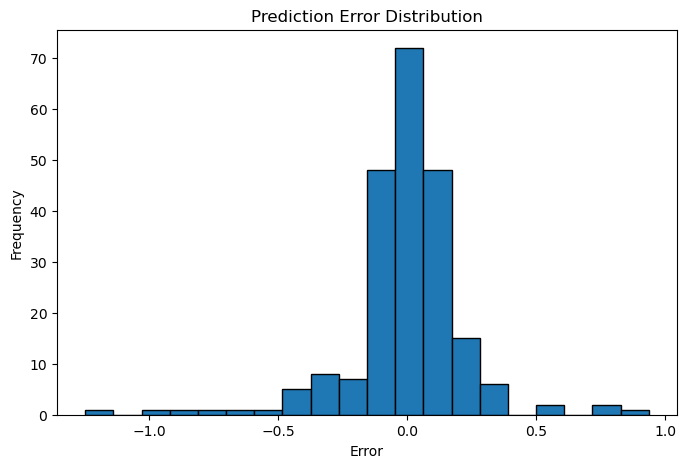

In [23]:
errors = y_test - pred

plt.figure(figsize=(8,5))
plt.hist(errors, bins=20, edgecolor="black")

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

In [24]:
sample_student = X_test.iloc[0]

model.predict([sample_student])

d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([7.590375])

In [25]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10)

depression                      0.457615
self_esteem                     0.304841
anxiety_level                   0.124406
teacher_student_relationship    0.046007
safety                          0.036450
headache                        0.011078
future_career_concerns          0.003586
blood_pressure                  0.003416
peer_pressure                   0.002260
social_support                  0.002168
dtype: float64

In [26]:
train_pred = model.predict(X_train)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, pred))

Train R2: 0.998799913754821
Test R2: 0.991267292298848


In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation R2:", scores.mean())

Cross Validation R2: 0.9910442626520624


In [46]:
df["MindMeter"].describe()

count    1100.000000
mean        4.266409
std         2.441427
min         0.200000
25%         1.662500
50%         4.056250
75%         6.778125
max         8.925000
Name: MindMeter, dtype: float64

In [28]:
!pip install shap

In [29]:
import shap
shap.initjs()

In [30]:
explainer = shap.TreeExplainer(model)

In [31]:
shap_values = explainer.shap_values(X_test)

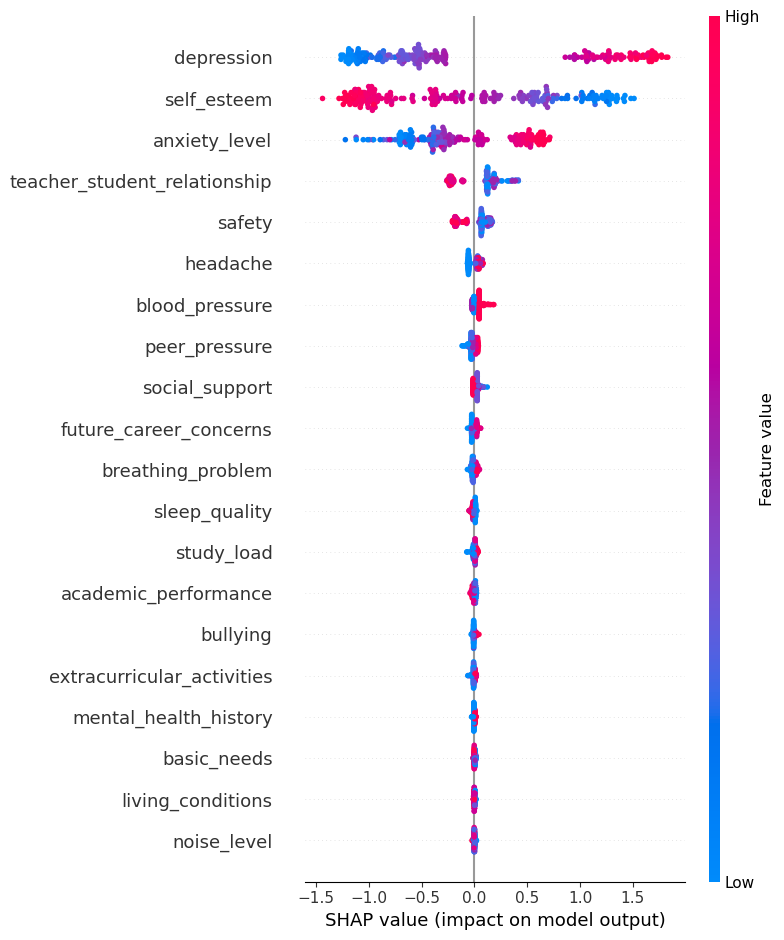

In [32]:
shap.summary_plot(shap_values, X_test)

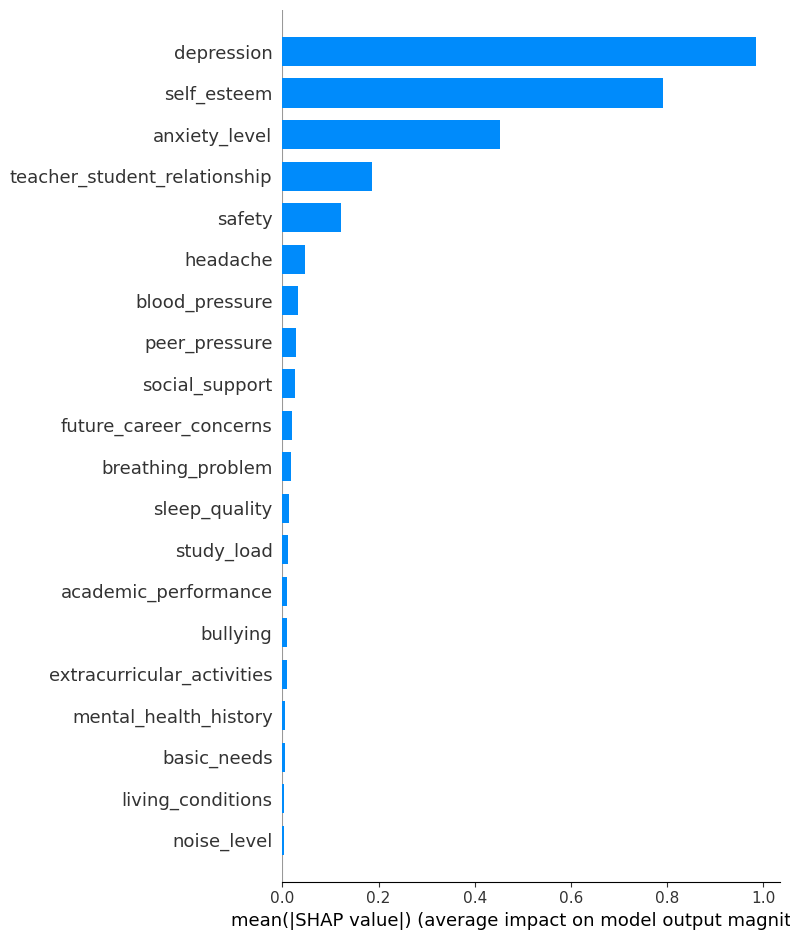

In [33]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)


In [34]:
student = X_test.iloc[0]

In [35]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    student
)

In [36]:
import numpy as np

def explain_prediction(index):

    values = shap_values[index]
    features = X_test.iloc[index]

    contribution = pd.Series(values, index=X_test.columns)
    contribution = contribution.sort_values(key=abs, ascending=False)

    print("Top Factors Affecting MindMeter Score:\n")

    for feature in contribution.head(5).index:
        impact = contribution[feature]

        if impact > 0:
            print(f"⬆ {feature} increased risk")
        else:
            print(f"⬇ {feature} reduced risk")

In [37]:
explain_prediction(0)

Top Factors Affecting MindMeter Score:

⬆ depression increased risk
⬆ anxiety_level increased risk
⬆ self_esteem increased risk
⬆ teacher_student_relationship increased risk
⬆ safety increased risk


In [38]:
ADVICE_MAP = {

    "anxiety_level":
        "Try short breathing resets or journaling to calm mental overload.",

    "sleep_quality":
        "Improve sleep consistency. Avoid screens before bedtime.",

    "study_load":
        "Break study sessions into smaller focused intervals.",

    "peer_pressure":
        "Focus on your own progress rather than comparison.",

    "social_support":
        "Connect regularly with supportive friends or mentors.",

    "depression":
        "Consider speaking with someone you trust or a counselor.",

    "academic_performance":
        "Aim for steady improvement instead of perfection.",

    "bullying":
        "Seek safe support spaces and trusted guidance.",

    "mental_health_history":
        "Schedule regular recovery and reflection time."
}

In [39]:
import pandas as pd

def get_top_factors(shap_values, X_test, index, top_n=5):

    contributions = pd.Series(
        shap_values[index],
        index=X_test.columns
    )

    contributions = contributions.sort_values(
        key=abs,
        ascending=False
    )

    return contributions.head(top_n)

In [40]:
def generate_advice(shap_values, X_test, index):

    top_factors = get_top_factors(shap_values, X_test, index)

    advice = []

    for feature, impact in top_factors.items():

        if impact > 0:   # only risk-increasing factors
            if feature in ADVICE_MAP:
                advice.append(
                    f"{feature.replace('_',' ').title()}: "
                    + ADVICE_MAP[feature]
                )

    return advice

In [41]:
def comfort_message(score):

    if score > 75:
        return "You're not failing — you're carrying a heavy load right now."

    elif score > 50:
        return "You're managing many pressures. Small adjustments can help restore balance."

    return "You're maintaining a healthy balance. Keep protecting your wellbeing."

In [42]:
index = 0

predicted_score = model.predict([X_test.iloc[index]])[0]

advice = generate_advice(shap_values, X_test, index)

print("MindMeter Score:", round(predicted_score,2))
print("\nPersonalized Advice:\n")

for tip in advice:
    print("•", tip)

print("\nMessage:")
print(comfort_message(predicted_score))

MindMeter Score: 7.59

Personalized Advice:

• Depression: Consider speaking with someone you trust or a counselor.
• Anxiety Level: Try short breathing resets or journaling to calm mental overload.

Message:
You're maintaining a healthy balance. Keep protecting your wellbeing.


d:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [45]:
import joblib

# your feature list used during training
features = X.columns.tolist()

joblib.dump(features, "../model/features.pkl")

['../model/features.pkl']